In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import robust_scale,minmax_scale
from sklearn.model_selection import KFold

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import L1L2, L1, L2
from tensorflow.keras.optimizers import Adam

/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
data = pd.read_csv("./../Data_Demo/input_train.csv", header=None)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,681,682,683,684,685,686,687,688,689,690
0,84,600,171.0,12.0,4.0,-17280.0,10.0,1.0,3.0,-890.0,...,2.0,4.0,2.0,5.0,6.0,1.0,2.0,0.0,1.0,2.0
1,63,600,171.0,12.0,4.0,-17280.0,5.0,0.0,0.0,-680.0,...,2.0,4.0,2.0,5.0,6.0,1.0,2.0,0.0,1.0,2.0
2,78,600,171.0,12.0,4.0,-17280.0,10.0,1.0,3.0,-890.0,...,2.0,4.0,2.0,5.0,6.0,1.0,2.0,0.0,1.0,2.0
3,96,600,171.0,12.0,4.0,-17280.0,10.0,1.0,3.0,-890.0,...,2.0,4.0,2.0,5.0,6.0,1.0,2.0,0.0,1.0,2.0
4,82,3043,922.0,54.0,23.0,-128650.0,8.0,0.0,7.0,-1160.0,...,5.0,10.0,6.0,4.0,11.0,2.0,3.0,9.0,6.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45972,115,588,167.0,11.0,4.0,-18440.0,-1.0,-1.0,-1.0,0.0,...,0.0,2.0,2.0,4.0,5.0,3.0,3.0,3.0,3.0,1.0
45973,71,2036,605.0,30.0,15.0,-50020.0,17.0,1.0,8.0,-290.0,...,4.0,17.0,13.0,9.0,10.0,19.0,19.0,14.0,20.0,32.0
45974,73,795,220.0,14.0,5.0,-23880.0,15.0,0.0,2.0,-1760.0,...,0.0,3.0,2.0,3.0,3.0,12.0,4.0,4.0,11.0,14.0
45975,78,4296,1242.0,72.0,34.0,-156380.0,7.0,0.0,14.0,2120.0,...,3.0,20.0,22.0,16.0,15.0,8.0,19.0,14.0,22.0,42.0


In [4]:
negative_pairs_path = "./../Data_Demo/txt_interac/negative_pairs.txt"
positive_pairs_path = "./../Data_Demo/txt_interac/mirnas_lncrnas_validated_positive_pairs.txt"

positive_pairs = [[line.strip().split(",")[0],line.strip().split(",")[1]] for line in open(positive_pairs_path,"r").readlines()]
negative_pairs = [[line.strip().split(",")[0],line.strip().split(",")[1]] for line in open(negative_pairs_path,"r").readlines()]

labels = [1] * len(positive_pairs) + [0] * len(negative_pairs)
labels = pd.DataFrame(labels)

del positive_pairs
del negative_pairs

In [5]:
train_data, test_data, train_label, test_label = train_test_split(data, labels, test_size=0.25, random_state=42)
dim = len(train_data.columns)

In [6]:
k =  5
kf = KFold(n_splits=k,shuffle=True,random_state=42)
histories = []
scores = []

In [7]:
def get_model():
    model = Sequential()
    model.add(BatchNormalization(input_shape = (dim,)))
    model.add(Dense(150,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.3))
    model.add(Dense(75,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.3))
    model.add(Dense(20,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.3))
    model.add(Dense(1,activation = 'sigmoid', bias_initializer = 'zeros', kernel_initializer = 'glorot_normal'))
    return model

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5945 - loss: 1.6437 - val_accuracy: 0.7776 - val_loss: 1.3418
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7696 - loss: 1.2659 - val_accuracy: 0.8660 - val_loss: 0.9932
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8622 - loss: 0.9809 - val_accuracy: 0.8701 - val_loss: 0.8506
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8819 - loss: 0.8214 - val_accuracy: 0.8718 - val_loss: 0.7367
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8801 - loss: 0.7098 - val_accuracy: 0.8734 - val_loss: 0.6412
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8824 - loss: 0.6157 - val_accuracy: 0.8763 - val_loss: 0.5694
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8814 - loss: 0.5486 - val_accuracy: 0.8768 - val_loss: 0.5065
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8875 - loss: 0.4841 - val_accuracy: 0.8759

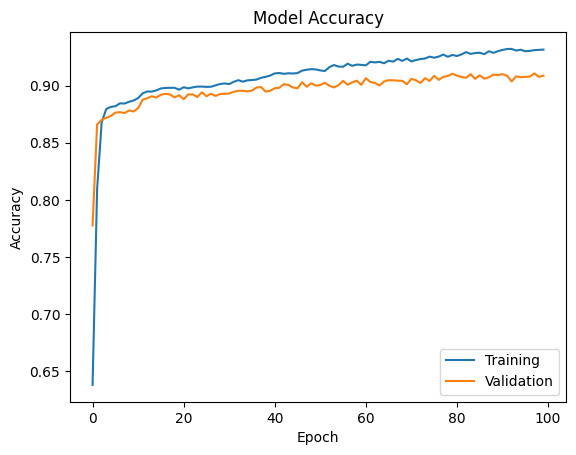

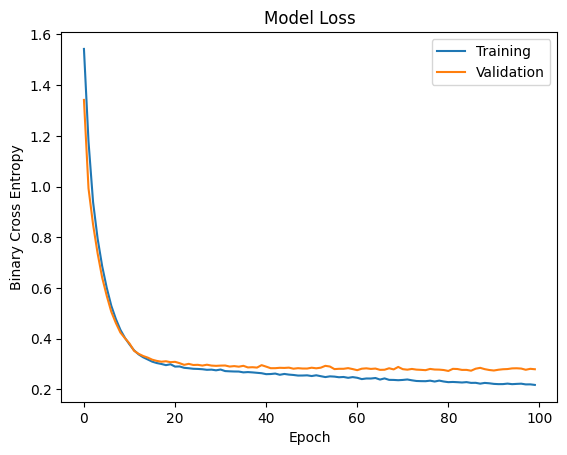

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5793 - loss: 1.7541 - val_accuracy: 0.7460 - val_loss: 1.4272
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7190 - loss: 1.3841 - val_accuracy: 0.8789 - val_loss: 1.0903
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8353 - loss: 1.1132 - val_accuracy: 0.8843 - val_loss: 0.9302
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8650 - loss: 0.9479 - val_accuracy: 0.8879 - val_loss: 0.8154
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8736 - loss: 0.8307 - val_accuracy: 0.8878 - val_loss: 0.7238
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8803 - loss: 0.7224 - val_accuracy: 0.8897 - val_loss: 0.6444
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8782 - loss: 0.6500 - val_accuracy: 0.8902 - val_loss: 0.5741
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8790 - loss: 0.5829 - val_accuracy: 0.8918

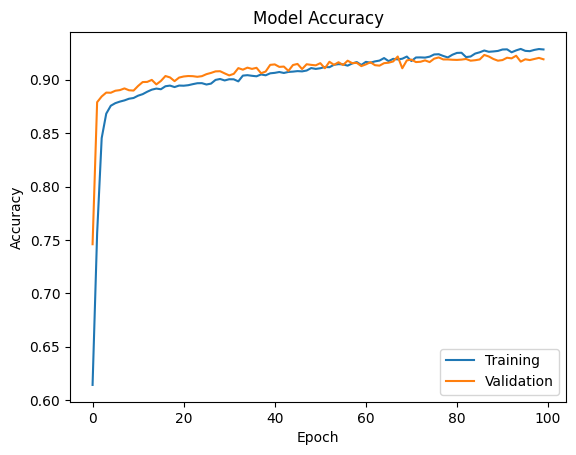

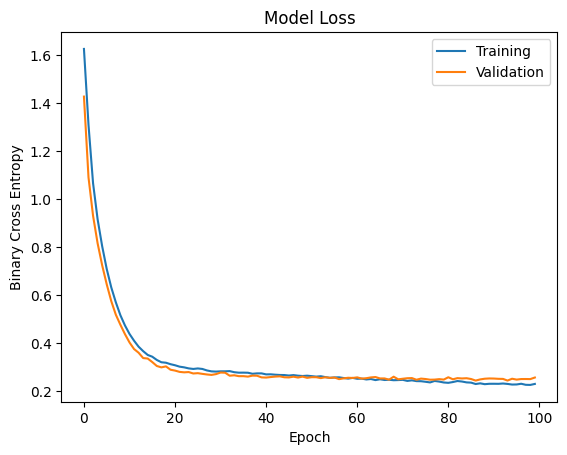

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5735 - loss: 1.7363 - val_accuracy: 0.7626 - val_loss: 1.4244
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7218 - loss: 1.3646 - val_accuracy: 0.8772 - val_loss: 1.0737
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8459 - loss: 1.0805 - val_accuracy: 0.8818 - val_loss: 0.9153
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8695 - loss: 0.9242 - val_accuracy: 0.8857 - val_loss: 0.8022
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8767 - loss: 0.8082 - val_accuracy: 0.8857 - val_loss: 0.7087
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8755 - loss: 0.7160 - val_accuracy: 0.8860 - val_loss: 0.6260
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8815 - loss: 0.6307 - val_accuracy: 0.8873 - val_loss: 0.5600
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8813 - loss: 0.5633 - val_accuracy: 0.8866

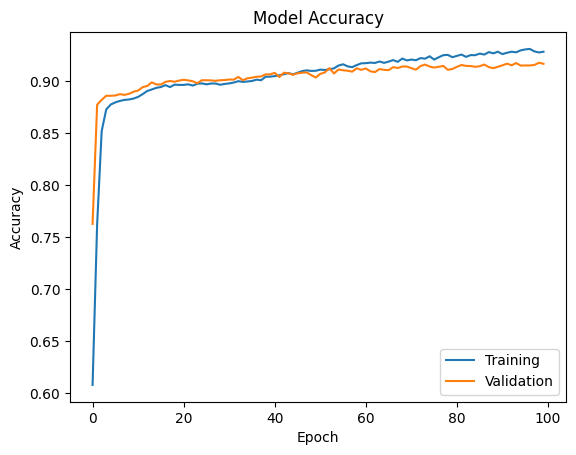

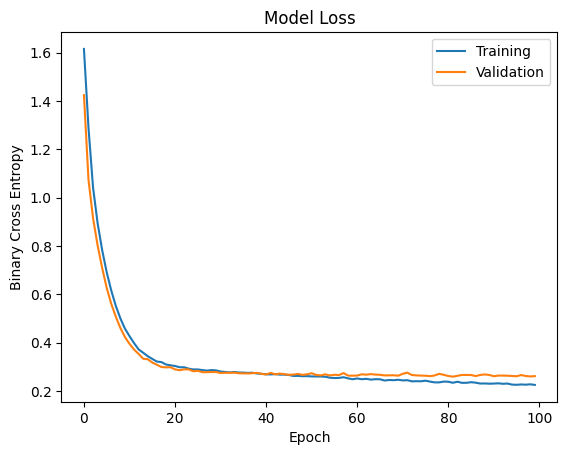

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5945 - loss: 1.7025 - val_accuracy: 0.7948 - val_loss: 1.3825
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7578 - loss: 1.3297 - val_accuracy: 0.8814 - val_loss: 1.0617
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8537 - loss: 1.0740 - val_accuracy: 0.8843 - val_loss: 0.9196
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8753 - loss: 0.9157 - val_accuracy: 0.8827 - val_loss: 0.8132
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8756 - loss: 0.8073 - val_accuracy: 0.8865 - val_loss: 0.7130
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8769 - loss: 0.7138 - val_accuracy: 0.8860 - val_loss: 0.6364
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8792 - loss: 0.6359 - val_accuracy: 0.8854 - val_loss: 0.5706
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8810 - loss: 0.5697 - val_accuracy: 0.8876

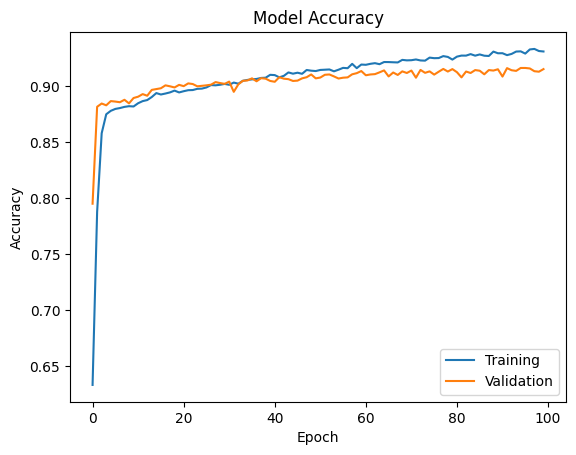

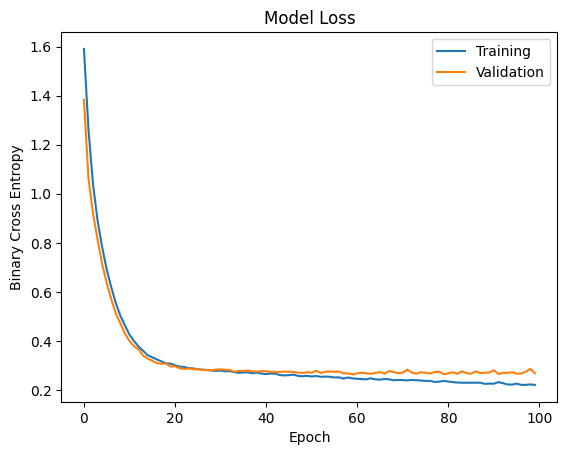

Epoch 1/100


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5849 - loss: 1.7153 - val_accuracy: 0.7594 - val_loss: 1.4322
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7325 - loss: 1.3681 - val_accuracy: 0.8669 - val_loss: 1.0902
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8523 - loss: 1.0842 - val_accuracy: 0.8706 - val_loss: 0.9416
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8737 - loss: 0.9272 - val_accuracy: 0.8730 - val_loss: 0.8302
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8804 - loss: 0.8080 - val_accuracy: 0.8741 - val_loss: 0.7352
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8841 - loss: 0.7123 - val_accuracy: 0.8756 - val_loss: 0.6539
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8814 - loss: 0.6338 - val_accuracy: 0.8754 - val_loss: 0.5837
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8831 - loss: 0.5708 - val_accuracy: 0.8759

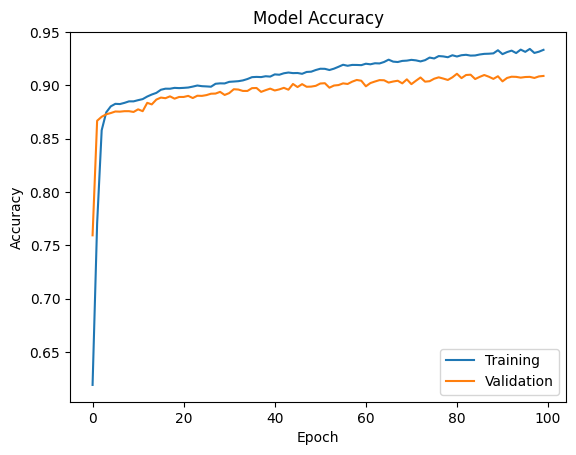

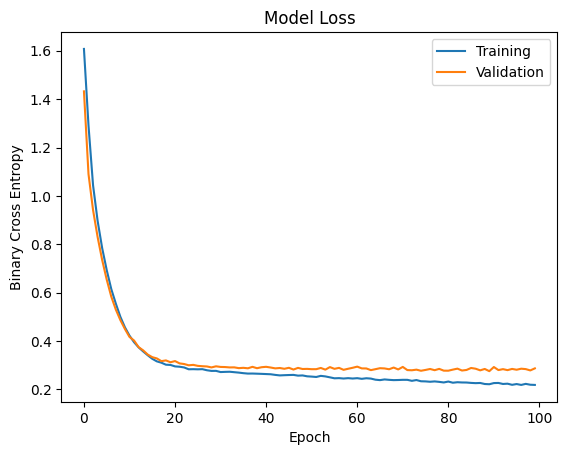

In [8]:
for train_index, test_index in kf.split(train_data):
    data_train, data_val = train_data.iloc[train_index], train_data.iloc[test_index]
    label_train, label_val = train_label.iloc[train_index], train_label.iloc[test_index]

    model = get_model()
    opt = Adam(0.0005)
    model.compile(optimizer=opt,loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(data_train,label_train,batch_size=256,epochs=100, validation_data = (data_val, label_val))
    
    score = model.evaluate(data_val, label_val)
    histories.append(history)
    scores.append(scores)

    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Binary Cross Entropy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper right')
    plt.show()